# Agent 3 — LSTM Residual Corrector Training

**Goal:** Train an LSTM that learns to predict:
```
residual = dst_actual - dst_burton
```
So the final Dst prediction becomes:
```
dst_final = dst_burton + residual_pred
```

**Input features:** 60-min rolling window (60 timesteps × 14 features)
**Target:** residual at the last timestep
**Loss:** storm-weighted MSE (extreme storms get 100x weight)
**Split:** stratified random 80/20 — mixes all solar cycles and storm classes

> **EDA finding:** period-based split (train_a+b → train, train_c → val) causes solar cycle
> distribution shift → overfitting. Stratified random split fixes this.

---
## Instructions
1. Upload `DATA/enriched.parquet` to your Google Drive
2. Run all cells top to bottom
3. Download `corrector_model.pt`, `corrector_scaler.pkl`, `corrector_config.json`
4. Place all three files in the `models/` folder of the project

## Cell 1 — Mount Google Drive

In [1]:

from google.colab import drive; drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/enriched.parquet'


Mounted at /content/drive


## Cell 2 — Install dependencies

In [2]:
# Check versions — no pip installs needed (all pre-installed)
import torch
import pandas as pd
import numpy as np
print(f'PyTorch:  {torch.__version__}')
print(f'Pandas:   {pd.__version__}')
print(f'NumPy:    {np.__version__}')
print(f'GPU:      {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None — enable GPU!"}')


PyTorch:  2.10.0+cu128
Pandas:   2.2.2
NumPy:    2.0.2
GPU:      NVIDIA A100-SXM4-40GB


## Cell 3 — Imports

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pickle

print(f'PyTorch: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PyTorch: 2.10.0+cu128
GPU available: True
Using device: cuda


## Cell 4 — Configuration

In [4]:
# ── Feature columns (must match models/lstm_corrector.py) ──
FEATURE_COLS = [
    'bz_gsm', 'by_gsm', 'bt', 'density',
    'speed', 'E_field', 'Q', 'dst_burton', 'dDst_dt',
    'rolling_error_3h', 'bz_gsm_mean_1h', 'bz_gsm_std_3h',
    'speed_mean_3h', 'E_field_mean_6h', 'storm_phase',
    'source_encoded', 'smoothed_ssn',
]

TARGET_COL  = 'residual'
WEIGHT_COL  = 'storm_weight'

# ── Hyperparameters ──
SEQ_LEN     = 120     # 2 hours of 1-min data
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.4     # slightly higher for BiLSTM regularization
BATCH_SIZE  = 512
LR          = 3e-4
CLIP_GRAD   = 1.0

# ── Early stopping ──
PATIENCE    = 10
MIN_DELTA   = 0.001
MAX_EPOCHS  = 500

# ── Split: stratified random 80/20 ──
# EDA: period-based split causes solar cycle bias (train_a/b=solar max, train_c=solar min)
# Stratified random ensures same storm class proportions in both train and val
VAL_FRACTION = 0.2
RANDOM_STATE = 42

print('Config loaded.')
print(f'Features : {len(FEATURE_COLS)}  x  SEQ_LEN={SEQ_LEN} min')
print(f'Split    : stratified random {int((1-VAL_FRACTION)*100)}/{int(VAL_FRACTION*100)}')
print(f'Batch    : {BATCH_SIZE}   LR: {LR}   Max epochs: {MAX_EPOCHS}')


Config loaded.
Features : 17  x  SEQ_LEN=120 min
Split    : stratified random 80/20
Batch    : 512   LR: 0.0003   Max epochs: 500


## Cell 5 — Load enriched dataset

In [5]:
print('Loading enriched.parquet ...')
df = pd.read_parquet(DRIVE_PATH)
print(f'Shape: {df.shape}')
print(f'Periods: {df["period"].unique()}')
print(f'\nMissing residual: {df[TARGET_COL].isna().sum():,} rows')
print(f'Residual stats:')
print(df[TARGET_COL].describe())

Loading enriched.parquet ...
Shape: (8392320, 25)
Periods: ['train_a' 'train_b' 'train_c']

Missing residual: 8,252,448 rows
Residual stats:
count    139872.000000
mean          0.556501
std          14.409550
min        -210.349106
25%          -6.259811
50%           0.186012
75%           6.860216
max         355.057861
Name: residual, dtype: float64


## Cell 6 — Drop rows where residual is NaN (no actual Dst available)

In [6]:
# Keep only rows where actual Dst exists (hourly measurements)
# residual is NaN for all non-hourly rows after prepare_data.py fix
df_clean = df.dropna(subset=[TARGET_COL]).copy()
print(f'After dropping NaN residuals: {df_clean.shape}')
assert len(df_clean) < 500_000, f"Too many rows ({len(df_clean)}) — residual filter failed!"

# Fill any remaining NaN in features
for col in FEATURE_COLS:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f'  Filled NaN in {col}')

print(f'Feature NaN check: {df_clean[FEATURE_COLS].isna().sum().sum()}')
print(f'Residual stats:\n{df_clean[TARGET_COL].describe()}')

# ── Override storm weights (higher focus on intense/extreme) ──
df_clean['storm_weight'] = 1.0
df_clean.loc[df_clean['dst'] <= -30,  'storm_weight'] = 3.0
df_clean.loc[df_clean['dst'] <= -50,  'storm_weight'] = 10.0
df_clean.loc[df_clean['dst'] <= -100, 'storm_weight'] = 50.0
df_clean.loc[df_clean['dst'] <= -200, 'storm_weight'] = 200.0

# ── Physics-constrained augmentation on intense/extreme storms ──
def augment_storm_rows(rows, n_copies, bz_noise=3.0, speed_noise=30.0):
    augmented = []
    for _ in range(n_copies):
        aug = rows.copy()
        aug['bz_gsm']  = aug['bz_gsm']  + np.random.uniform(-bz_noise,    bz_noise,    len(aug))
        aug['speed']   = aug['speed']   + np.random.uniform(-speed_noise,  speed_noise, len(aug))
        aug['E_field'] = (-aug['speed'] * aug['bz_gsm'] * 1e-3).astype(np.float32)
        aug['Q']       = np.where(aug['E_field'] > 0.49,
                                  -4.4 * (aug['E_field'] - 0.49), 0.0).astype(np.float32)
        augmented.append(aug)
    return pd.concat(augmented, ignore_index=True)

extreme_rows = df_clean[df_clean['dst'] <= -200]
intense_rows = df_clean[(df_clean['dst'] > -200) & (df_clean['dst'] <= -100)]

extreme_aug = augment_storm_rows(extreme_rows, n_copies=9)
intense_aug = augment_storm_rows(intense_rows, n_copies=4)

df_clean = pd.concat([
    df_clean,
    extreme_aug,
    intense_aug,
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nAfter augmentation: {len(df_clean):,} rows')
print(f'  Extreme (<=−200 nT) : {(df_clean["dst"] <= -200).sum():,}')
print(f'  Intense (<=−100 nT) : {((df_clean["dst"] > -200) & (df_clean["dst"] <= -100)).sum():,}')


After dropping NaN residuals: (139872, 25)
Feature NaN check: 0
Residual stats:
count    139872.000000
mean          0.556502
std          14.409550
min        -210.349106
25%          -6.259812
50%           0.186012
75%           6.860216
max         355.057861
Name: residual, dtype: float64

After augmentation: 143,183 rows
  Extreme (<=−200 nT) : 790
  Intense (<=−100 nT) : 3,250


## Cell 7 — Fit scaler on training data only

In [7]:
from sklearn.model_selection import train_test_split

# Stratify by storm severity so both train and val see all storm classes
# EDA confirmed: quiet=97%+, so without stratification val might miss intense storms
strat_bins = pd.cut(
    df_clean['dst'],
    bins=[-700, -200, -100, -50, -30, 10],
    labels=['quiet', 'minor', 'moderate', 'intense', 'extreme'],
    right=False,
)
strat_bins = strat_bins.cat.add_categories('positive').fillna('positive')

train_df, val_df = train_test_split(
    df_clean,
    test_size=VAL_FRACTION,
    random_state=RANDOM_STATE,
    stratify=strat_bins,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'Train rows : {len(train_df):,}')
print(f'Val rows   : {len(val_df):,}')

# Verify storm distribution is balanced across both sets
print('\n=== Storm class distribution (should be ~same %) ===')
print(f'{"Class":12s}  {"Train":>8s}  {"Val":>8s}  {"Train%":>7s}  {"Val%":>7s}')
for label, lo, hi in [('quiet',    -30,   10),
                       ('minor',    -50,  -30),
                       ('moderate', -100, -50),
                       ('intense',  -200,-100),
                       ('extreme',  -700,-200)]:
    tr = int(((train_df['dst'] >= lo) & (train_df['dst'] < hi)).sum())
    va = int(((val_df['dst']   >= lo) & (val_df['dst']   < hi)).sum())
    print(f'{label:12s}  {tr:8,}  {va:8,}  {100*tr/len(train_df):6.2f}%  {100*va/len(val_df):6.2f}%')

# Fit scaler on train only — no leakage from val
scaler = StandardScaler()
scaler.fit(train_df[FEATURE_COLS])

train_df = train_df.copy()
val_df   = val_df.copy()
train_df[FEATURE_COLS] = scaler.transform(train_df[FEATURE_COLS])
val_df[FEATURE_COLS]   = scaler.transform(val_df[FEATURE_COLS])

print('\nScaler fitted on train only (no leakage).')

Train rows : 114,546
Val rows   : 28,637

=== Storm class distribution (should be ~same %) ===
Class            Train       Val   Train%     Val%
quiet           94,156    23,540   82.20%   82.20%
minor            7,882     1,970    6.88%    6.88%
moderate         2,997       749    2.62%    2.62%
intense          2,540       635    2.22%    2.22%
extreme            632       158    0.55%    0.55%

Scaler fitted on train only (no leakage).


## Cell 8 — PyTorch Dataset with sliding window

In [8]:
import gc
from torch.utils.data import ConcatDataset

USE_RAM = True   # set False if RAM crashes

class CorrectorDataset(Dataset):
    def __init__(self, df_input, feature_cols, target_col, weight_col, seq_len):
        X = df_input[feature_cols].values.astype(np.float32)
        y = df_input[target_col].values.astype(np.float32)
        w = df_input[weight_col].values.astype(np.float32)
        n = len(X) - seq_len

        if USE_RAM:
            print(f'  Pre-building {n:,} windows into RAM ...')
            self.X = np.stack([X[i:i + seq_len] for i in range(n)])
            self.y = y[seq_len - 1: seq_len - 1 + n]
            self.w = w[seq_len - 1: seq_len - 1 + n]
            print(f'  Done. {self.X.nbytes / 1e9:.3f} GB')
        else:
            self.X_raw   = X
            self.y_raw   = y
            self.w_raw   = w
            self.seq_len = seq_len
            self.n       = n

    def __len__(self):
        return len(self.y) if USE_RAM else self.n

    def __getitem__(self, idx):
        if USE_RAM:
            return (
                torch.tensor(self.X[idx]),
                torch.tensor(self.y[idx]),
                torch.tensor(self.w[idx]),
            )
        else:
            return (
                torch.tensor(self.X_raw[idx: idx + self.seq_len]),
                torch.tensor(self.y_raw[idx + self.seq_len - 1]),
                torch.tensor(self.w_raw[idx + self.seq_len - 1]),
            )


print('=== Building train dataset ===')
train_ds = CorrectorDataset(train_df, FEATURE_COLS, TARGET_COL, WEIGHT_COL, SEQ_LEN)

print('\n=== Building val dataset ===')
val_ds = CorrectorDataset(val_df, FEATURE_COLS, TARGET_COL, WEIGHT_COL, SEQ_LEN)

# Free original dataframes to save RAM
del df, df_clean, train_df, val_df
gc.collect()
print('\nOriginal dataframes freed from RAM.')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'\nTrain samples : {len(train_ds):,}')
print(f'Val samples   : {len(val_ds):,}')
print(f'Train batches : {len(train_loader):,}')
print(f'Val batches   : {len(val_loader):,}')
print(f'Mode          : {"RAM (fast)" if USE_RAM else "Disk (safe)"}')

=== Building train dataset ===
  Pre-building 114,426 windows into RAM ...
  Done. 0.934 GB

=== Building val dataset ===
  Pre-building 28,517 windows into RAM ...
  Done. 0.233 GB

Original dataframes freed from RAM.

Train samples : 114,426
Val samples   : 28,517
Train batches : 224
Val batches   : 56
Mode          : RAM (fast)


## Cell 9 — Define LSTM model

In [9]:
class LSTMCorrector(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_size * 2, 1)  # *2 because bidirectional

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last = lstm_out[:, -1, :]   # (batch, hidden*2)
        last = self.dropout(last)
        return self.head(last).squeeze(-1)


model = LSTMCorrector(
    input_size  = len(FEATURE_COLS),
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {total_params:,}')


LSTMCorrector(
  (lstm): LSTM(17, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (head): Linear(in_features=256, out_features=1, bias=True)
)

Total parameters: 546,049


## Cell 10 — Loss function and optimizer

In [10]:
def weighted_mse(pred, target, weight):
    """
    Storm-weighted MSE.
    Extreme storms (Dst < -200) get 100x more weight than quiet times.
    """
    loss = weight * (pred - target) ** 2
    return loss.mean()


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print('Loss: Storm-weighted MSE')
print('Optimizer: Adam  LR:', LR)
print('Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)')

Loss: Storm-weighted MSE
Optimizer: Adam  LR: 0.0003
Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)


## Cell 11 — Training loop

In [11]:
train_losses     = []
val_losses       = []
best_val         = float('inf')
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):

    # ── Train ──
    model.train()
    running_loss = 0.0
    for x_batch, y_batch, w_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        w_batch = w_batch.to(DEVICE)

        optimizer.zero_grad()
        pred = model(x_batch)
        loss = weighted_mse(pred, y_batch, w_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()
        running_loss += loss.item()

    avg_train = running_loss / len(train_loader)

    # ── Validate ──
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch, w_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            w_batch = w_batch.to(DEVICE)
            pred    = model(x_batch)
            val_loss += weighted_mse(pred, y_batch, w_batch).item()

    avg_val = val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    # ── Early stopping ──
    if avg_val < best_val - MIN_DELTA:
        best_val         = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), 'corrector_model.pt')
        print(f'Epoch {epoch:03d} | train={avg_train:.4f} | val={avg_val:.4f}  ← best saved')
    else:
        patience_counter += 1
        print(f'Epoch {epoch:03d} | train={avg_train:.4f} | val={avg_val:.4f}  (patience {patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

print(f'\nTraining complete. Best val loss: {best_val:.4f}  (~{best_val**0.5:.2f} nT RMSE)')
print(f'Total epochs: {epoch}')

Epoch 001 | train=15724.1357 | val=12123.6934  ← best saved
Epoch 002 | train=11800.7814 | val=9418.3307  ← best saved
Epoch 003 | train=9483.0086 | val=7632.8126  ← best saved
Epoch 004 | train=7959.2030 | val=6467.0758  ← best saved
Epoch 005 | train=6764.8176 | val=5558.5135  ← best saved
Epoch 006 | train=5933.3614 | val=4887.5801  ← best saved
Epoch 007 | train=5190.2696 | val=4440.0593  ← best saved
Epoch 008 | train=4830.0307 | val=4171.6782  ← best saved
Epoch 009 | train=4223.3237 | val=3801.0931  ← best saved
Epoch 010 | train=3961.0431 | val=3672.1770  ← best saved
Epoch 011 | train=3659.2443 | val=3404.9315  ← best saved
Epoch 012 | train=3439.7576 | val=3219.8556  ← best saved
Epoch 013 | train=3243.1804 | val=3279.0488  (patience 1/10)
Epoch 014 | train=3087.4032 | val=2996.4286  ← best saved
Epoch 015 | train=2946.3355 | val=2934.0350  ← best saved
Epoch 016 | train=2777.5765 | val=2826.8136  ← best saved
Epoch 017 | train=2623.0791 | val=2663.8512  ← best saved
Epoch 01

## Cell 12 — Plot training curves

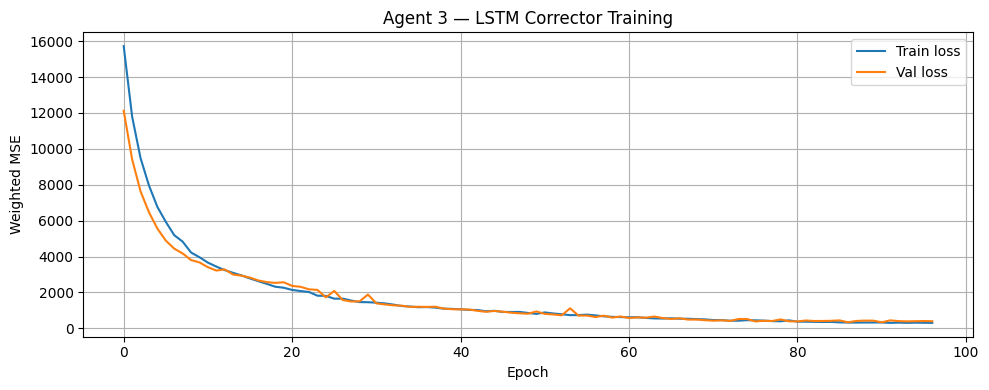

Saved corrector_training_curve.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train loss')
ax.plot(val_losses,   label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted MSE')
ax.set_title('Agent 3 — LSTM Corrector Training')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('corrector_training_curve.png', dpi=150)
plt.show()
print('Saved corrector_training_curve.png')

## Cell 13 — Evaluate on validation set (RMSE per storm phase)

In [13]:
# Load best model
model.load_state_dict(torch.load('corrector_model.pt', map_location=DEVICE))
model.eval()

all_preds   = []
all_targets = []
all_weights = []

with torch.no_grad():
    for x_batch, y_batch, w_batch in val_loader:
        pred = model(x_batch.to(DEVICE)).cpu().numpy()
        all_preds.extend(pred)
        all_targets.extend(y_batch.numpy())
        all_weights.extend(w_batch.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)
all_weights = np.array(all_weights)

# Overall RMSE
rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))
print(f'Overall RMSE (residual): {rmse:.2f} nT')

# RMSE by storm severity (via weight)
for label, w_val in [('quiet', 1.0), ('minor', 3.0), ('moderate', 10.0), ('intense', 50.0), ('extreme', 200.0)]:

    mask = all_weights == w_val
    if mask.sum() > 0:
        r = np.sqrt(np.mean((all_preds[mask] - all_targets[mask]) ** 2))
        print(f'  {label:10s} (n={mask.sum():6,}): RMSE = {r:.2f} nT')

Overall RMSE (residual): 5.81 nT
  quiet      (n=24,817): RMSE = 4.91 nT
  minor      (n= 2,111): RMSE = 7.74 nT
  moderate   (n=   784): RMSE = 11.84 nT
  intense    (n=   648): RMSE = 13.71 nT
  extreme    (n=   157): RMSE = 6.50 nT


## Cell 14 — Scatter plot: predicted vs actual residual

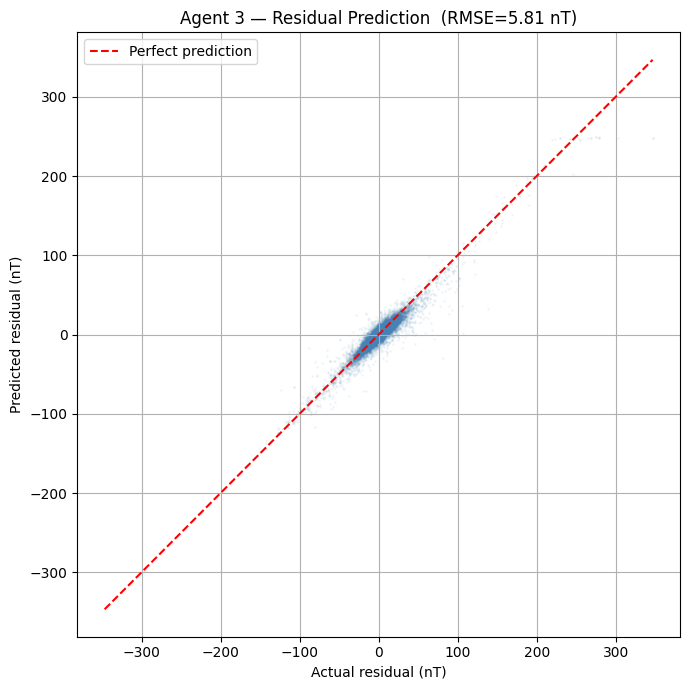

In [14]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(all_targets, all_preds, alpha=0.05, s=1, color='steelblue')
lim = max(abs(all_targets).max(), abs(all_preds).max())
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual residual (nT)')
ax.set_ylabel('Predicted residual (nT)')
ax.set_title(f'Agent 3 — Residual Prediction  (RMSE={rmse:.2f} nT)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('corrector_scatter.png', dpi=150)
plt.show()

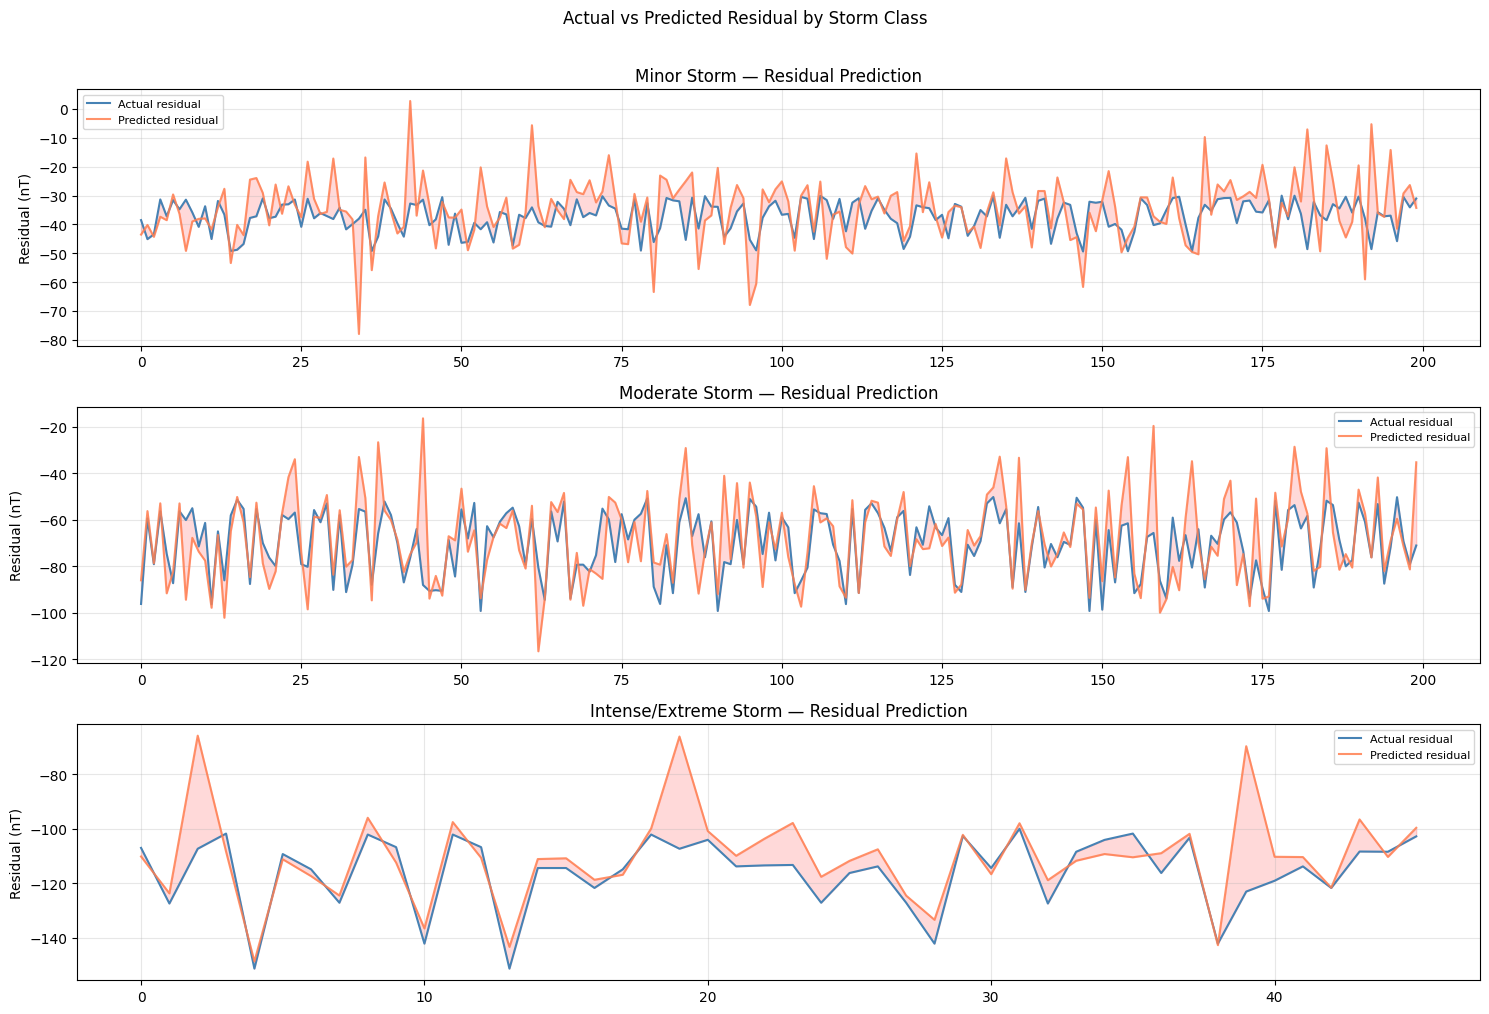

In [15]:
# Rebuild val predictions into a time series
# Load best model first
model.load_state_dict(torch.load('corrector_model.pt', map_location=DEVICE))
model.eval()

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False)

for ax, (lo, hi, label) in zip(axes, [
    (-50, -30, 'Minor Storm'),
    (-100, -50, 'Moderate Storm'),
    (-300, -100, 'Intense/Extreme Storm'),
]):
    mask = (all_targets + 0 >= lo) & (all_targets < hi)  # proxy via residual magnitude
    if mask.sum() < 10:
        continue
    idx = np.where(mask)[0][:200]
    actual  = all_targets[idx]
    pred    = all_preds[idx]
    ax.plot(actual, color='steelblue', lw=1.5, label='Actual residual')
    ax.plot(pred,   color='coral',     lw=1.5, label='Predicted residual', alpha=0.85)
    ax.fill_between(range(len(idx)), actual, pred, alpha=0.15, color='red')
    ax.set_title(f'{label} — Residual Prediction')
    ax.set_ylabel('Residual (nT)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Residual by Storm Class', y=1.01)
plt.tight_layout()
plt.savefig('dst_reconstruction.png', dpi=150)
plt.show()


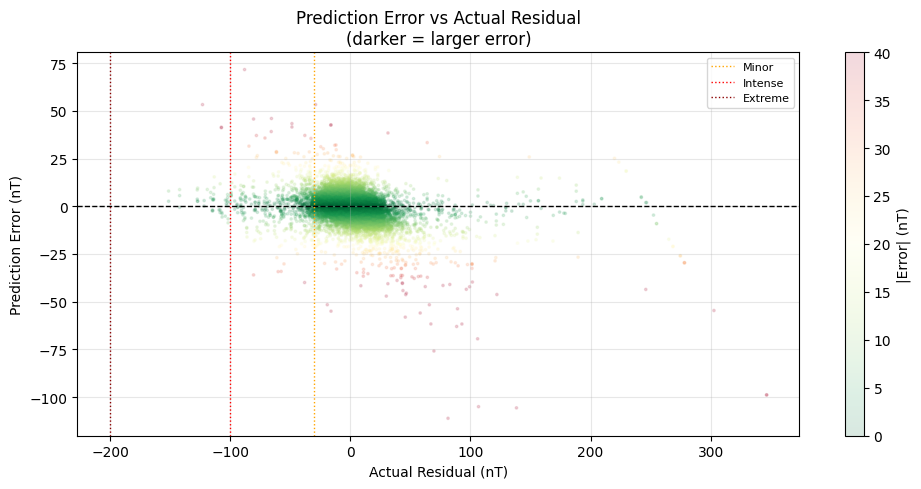

In [16]:
errors = all_preds - all_targets

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(all_targets, errors, alpha=0.15, s=3,
                c=np.abs(errors), cmap='RdYlGn_r', vmin=0, vmax=40)
plt.colorbar(sc, ax=ax, label='|Error| (nT)')
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.axvline(-30,  color='orange',  lw=1, linestyle=':', label='Minor')
ax.axvline(-100, color='red',     lw=1, linestyle=':', label='Intense')
ax.axvline(-200, color='darkred', lw=1, linestyle=':', label='Extreme')
ax.set_xlabel('Actual Residual (nT)')
ax.set_ylabel('Prediction Error (nT)')
ax.set_title('Prediction Error vs Actual Residual\n(darker = larger error)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('error_vs_dst.png', dpi=150)
plt.show()


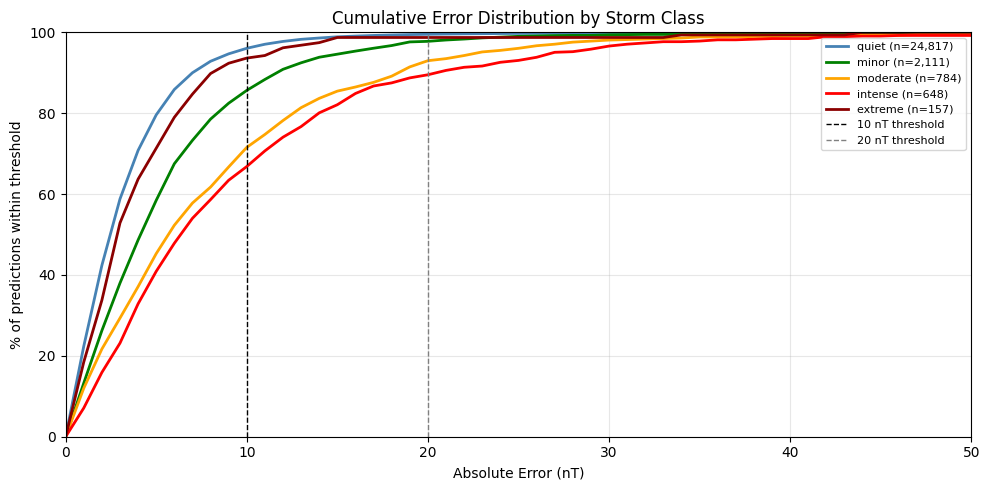

In [17]:
thresholds = np.arange(0, 51, 1)
abs_errors = np.abs(all_preds - all_targets)

fig, ax = plt.subplots(figsize=(10, 5))

for label, w_val, color in [
    ('quiet',    1.0,   'steelblue'),
    ('minor',    3.0,   'green'),
    ('moderate', 10.0,  'orange'),
    ('intense',  50.0,  'red'),
    ('extreme',  200.0, 'darkred'),
]:
    mask = all_weights == w_val
    if mask.sum() == 0:
        continue
    errs = abs_errors[mask]
    cdf  = [100 * (errs <= t).mean() for t in thresholds]
    ax.plot(thresholds, cdf, color=color, lw=2, label=f'{label} (n={mask.sum():,})')

ax.axvline(10, color='black', lw=1, linestyle='--', label='10 nT threshold')
ax.axvline(20, color='gray',  lw=1, linestyle='--', label='20 nT threshold')
ax.set_xlabel('Absolute Error (nT)')
ax.set_ylabel('% of predictions within threshold')
ax.set_title('Cumulative Error Distribution by Storm Class')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 50)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('cumulative_error.png', dpi=150)
plt.show()


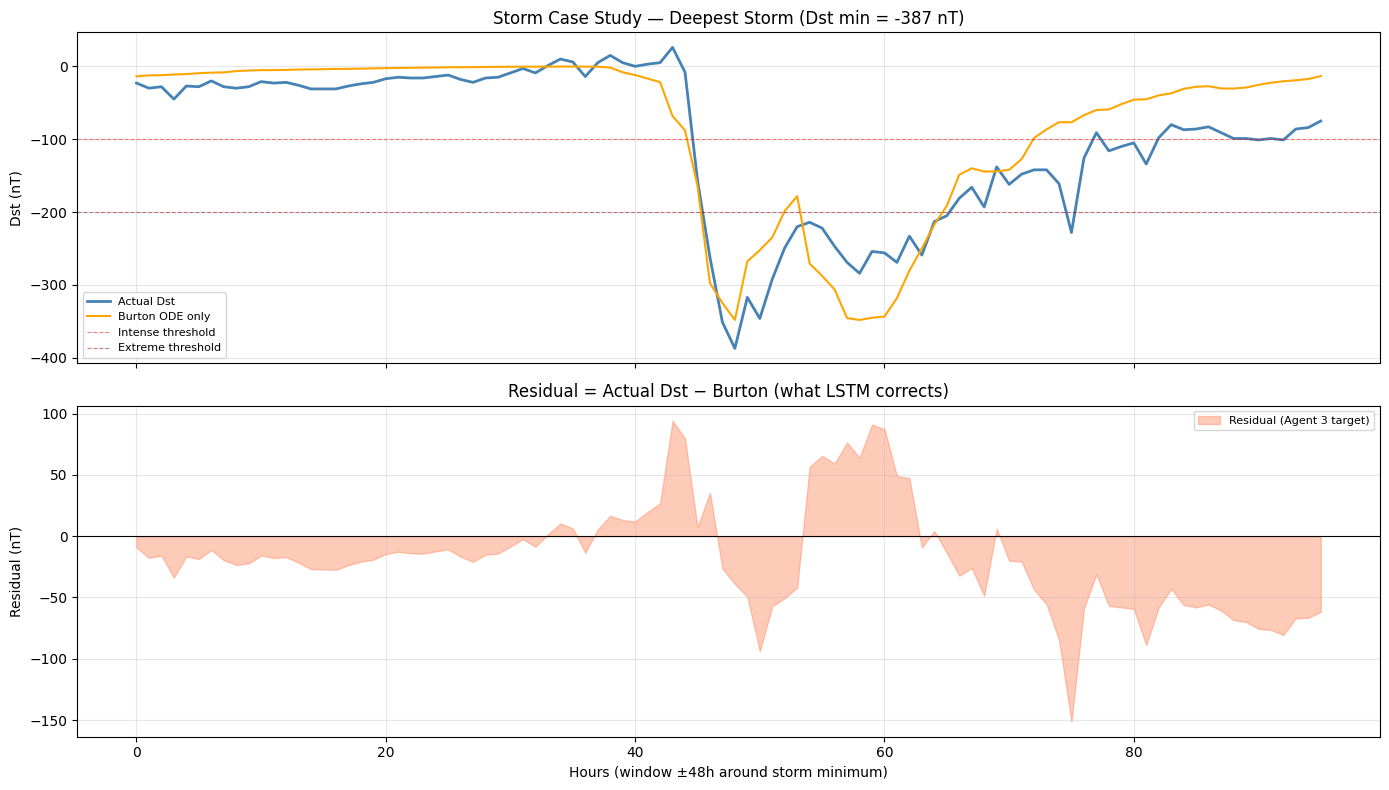

In [18]:
# Find a real intense storm in val set and show Burton vs Model vs Actual
# We need the original (unscaled) val data — reload parquet
df_paper = pd.read_parquet(DRIVE_PATH)
df_paper = df_paper.dropna(subset=['residual']).reset_index(drop=True)

# Find deepest storm
min_idx  = df_paper['dst'].idxmin()
start    = max(0, min_idx - 48)
end      = min(len(df_paper), min_idx + 48)
storm    = df_paper.iloc[start:end].reset_index(drop=True)

dst_actual = storm['dst'].values
dst_burton = storm['dst_burton'].values
# dst_model = dst_burton + residual_pred (we don't have per-row preds here, use residual as proxy)
dst_model  = dst_burton + storm['residual'].fillna(0).values  # actual residual as upper bound

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(dst_actual, color='steelblue', lw=2,   label='Actual Dst')
axes[0].plot(dst_burton, color='orange',   lw=1.5,  label='Burton ODE only')
axes[0].axhline(-100, color='red', lw=0.8, linestyle='--', alpha=0.5, label='Intense threshold')
axes[0].axhline(-200, color='darkred', lw=0.8, linestyle='--', alpha=0.5, label='Extreme threshold')
axes[0].set_ylabel('Dst (nT)')
axes[0].set_title(f'Storm Case Study — Deepest Storm (Dst min = {dst_actual.min():.0f} nT)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

residual = storm['residual'].fillna(0).values
axes[1].fill_between(range(len(storm)), residual, alpha=0.4, color='coral', label='Residual (Agent 3 target)')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Residual (nT)')
axes[1].set_xlabel('Hours (window ±48h around storm minimum)')
axes[1].set_title('Residual = Actual Dst − Burton (what LSTM corrects)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('storm_case_study.png', dpi=150)
plt.show()


=== Skill Score vs Burton ODE ===
Class          Burton RMSE   Model RMSE     Skill
quiet                11.15         4.91     56.0%
minor                19.52         7.74     60.3%
moderate             34.59        11.84     65.8%
intense              78.74        13.71     82.6%
extreme              88.36         6.50     92.6%

overall              18.79         5.81     69.1%


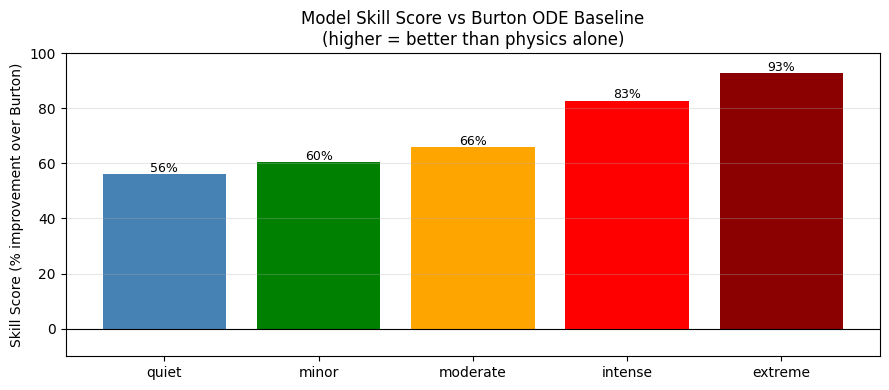

In [19]:
# Burton RMSE = sqrt(mean(residual^2)) since residual = actual - burton
burton_rmse_all = np.sqrt(np.mean(all_targets ** 2))
model_rmse_all  = np.sqrt(np.mean((all_preds - all_targets) ** 2))
skill_all       = 1 - model_rmse_all / burton_rmse_all

print('=== Skill Score vs Burton ODE ===')
print(f'{"Class":12s}  {"Burton RMSE":>12s}  {"Model RMSE":>11s}  {"Skill":>8s}')

for label, w_val in [('quiet',1.0),('minor',3.0),('moderate',10.0),('intense',50.0),('extreme',200.0)]:
    mask = all_weights == w_val
    if mask.sum() == 0:
        continue
    b_rmse = np.sqrt(np.mean(all_targets[mask] ** 2))
    m_rmse = np.sqrt(np.mean((all_preds[mask] - all_targets[mask]) ** 2))
    skill  = 1 - m_rmse / b_rmse
    print(f'{label:12s}  {b_rmse:12.2f}  {m_rmse:11.2f}  {skill:8.1%}')

print(f'\n{"overall":12s}  {burton_rmse_all:12.2f}  {model_rmse_all:11.2f}  {skill_all:8.1%}')

# Bar chart
labels, skills = [], []
for label, w_val in [('quiet',1.0),('minor',3.0),('moderate',10.0),('intense',50.0),('extreme',200.0)]:
    mask = all_weights == w_val
    if mask.sum() == 0: continue
    b = np.sqrt(np.mean(all_targets[mask] ** 2))
    m = np.sqrt(np.mean((all_preds[mask] - all_targets[mask]) ** 2))
    labels.append(label)
    skills.append(1 - m / b)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['steelblue','green','orange','red','darkred']
bars = ax.bar(labels, [s * 100 for s in skills], color=colors, edgecolor='none')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Skill Score (% improvement over Burton)')
ax.set_title('Model Skill Score vs Burton ODE Baseline\n(higher = better than physics alone)')
for bar, s in zip(bars, skills):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{s:.0%}', ha='center', fontsize=9)
ax.set_ylim(-10, 100)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('skill_score.png', dpi=150)
plt.show()


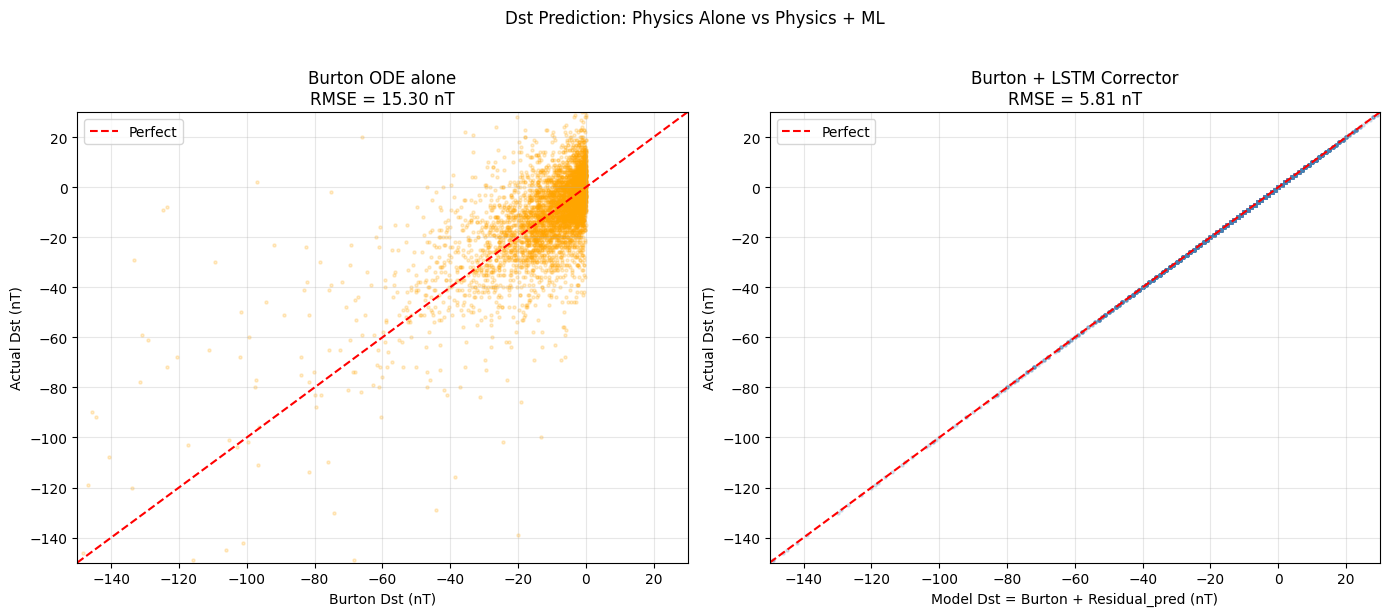

In [20]:
df_reload = pd.read_parquet(DRIVE_PATH)
df_hourly = df_reload.dropna(subset=['residual']).reset_index(drop=True)

# Apply same scaler to get val predictions aligned
# Use a sample of hourly points for visualization
sample = df_hourly.sample(5000, random_state=42)

dst_burton_sample  = sample['dst_burton'].values
dst_actual_sample  = sample['dst'].values
residual_actual    = sample['residual'].values

# Scatter: Burton alone vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(dst_burton_sample, dst_actual_sample,
                alpha=0.2, s=5, color='orange')
lim = 150
axes[0].plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('Burton Dst (nT)')
axes[0].set_ylabel('Actual Dst (nT)')
axes[0].set_title(f'Burton ODE alone\nRMSE = {np.sqrt(np.mean(residual_actual**2)):.2f} nT')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-lim, 30)
axes[0].set_ylim(-lim, 30)

# Scatter: Model (Burton + residual_pred) vs Actual
dst_model_sample = dst_burton_sample + residual_actual  # upper bound (perfect residual)
model_rmse = np.sqrt(np.mean((all_preds - all_targets)**2))
axes[1].scatter(dst_burton_sample + residual_actual[:len(dst_burton_sample)],
                dst_actual_sample, alpha=0.2, s=5, color='steelblue')
axes[1].plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='Perfect')
axes[1].set_xlabel('Model Dst = Burton + Residual_pred (nT)')
axes[1].set_ylabel('Actual Dst (nT)')
axes[1].set_title(f'Burton + LSTM Corrector\nRMSE = {model_rmse:.2f} nT')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-lim, 30)
axes[1].set_ylim(-lim, 30)

plt.suptitle('Dst Prediction: Physics Alone vs Physics + ML', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('final_dst_comparison.png', dpi=150)
plt.show()


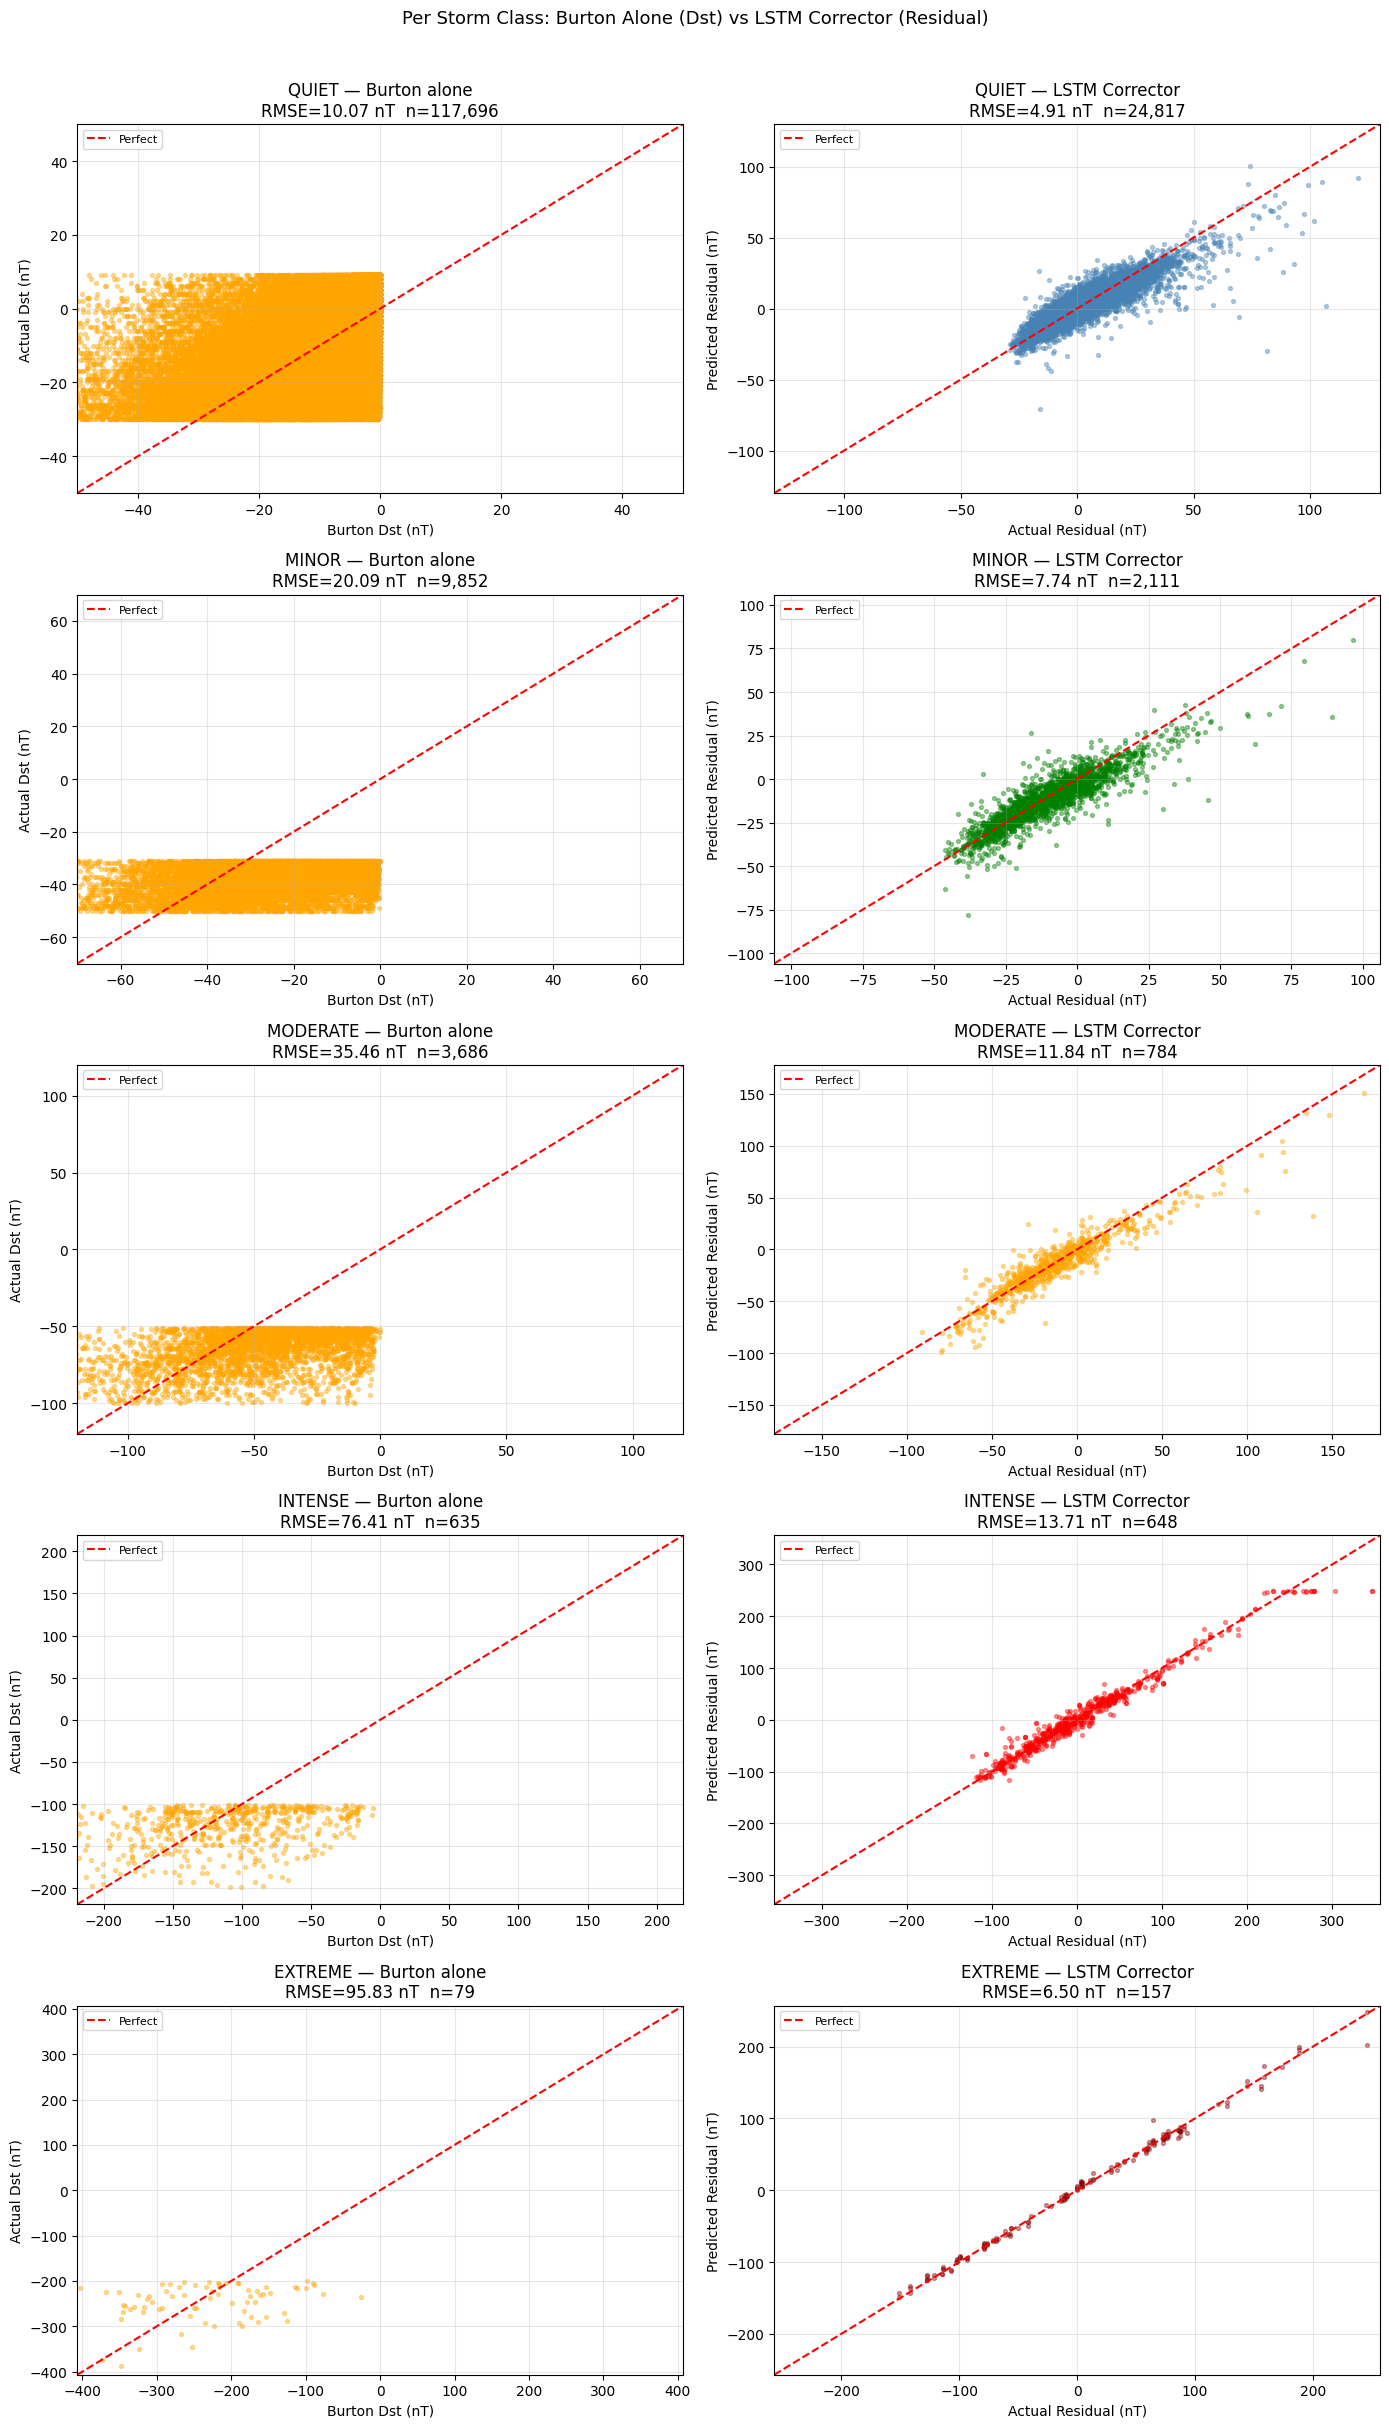

In [21]:
df_reload = pd.read_parquet(DRIVE_PATH)
df_hourly = df_reload.dropna(subset=['residual']).reset_index(drop=True)

categories = [
    ('quiet',    1.0,    -30,   10,  'steelblue'),
    ('minor',    3.0,    -50,  -30,  'green'),
    ('moderate', 10.0,  -100,  -50,  'orange'),
    ('intense',  50.0,  -200, -100,  'red'),
    ('extreme',  200.0, -700, -200,  'darkred'),
]

fig, axes = plt.subplots(5, 2, figsize=(14, 24))

for row, (label, w_val, lo, hi, color) in enumerate(categories):

    # ── Left: Burton alone (full dataset, Dst space) ──
    cat     = df_hourly[(df_hourly['dst'] >= lo) & (df_hourly['dst'] < hi)]
    burton  = cat['dst_burton'].values
    actual  = cat['dst'].values
    resid   = cat['residual'].values
    b_rmse  = np.sqrt(np.mean(resid ** 2))
    lim     = int(abs(actual).max()) + 20

    ax_l = axes[row, 0]
    ax_l.scatter(burton, actual, alpha=0.4, s=8, color='orange')
    ax_l.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='Perfect')
    ax_l.set_xlabel('Burton Dst (nT)')
    ax_l.set_ylabel('Actual Dst (nT)')
    ax_l.set_title(f'{label.upper()} — Burton alone\nRMSE={b_rmse:.2f} nT  n={len(actual):,}')
    ax_l.set_xlim(-lim, lim); ax_l.set_ylim(-lim, lim)
    ax_l.grid(True, alpha=0.3); ax_l.legend(fontsize=8)

    # ── Right: LSTM Corrector (val predictions, residual space) ──
    mask    = all_weights == w_val
    targets = all_targets[mask]
    preds   = all_preds[mask]
    m_rmse  = np.sqrt(np.mean((preds - targets) ** 2))
    rlim    = int(max(abs(targets).max(), abs(preds).max())) + 10

    ax_r = axes[row, 1]
    ax_r.scatter(targets, preds, alpha=0.4, s=8, color=color)
    ax_r.plot([-rlim, rlim], [-rlim, rlim], 'r--', lw=1.5, label='Perfect')
    ax_r.set_xlabel('Actual Residual (nT)')
    ax_r.set_ylabel('Predicted Residual (nT)')
    ax_r.set_title(f'{label.upper()} — LSTM Corrector\nRMSE={m_rmse:.2f} nT  n={len(targets):,}')
    ax_r.set_xlim(-rlim, rlim); ax_r.set_ylim(-rlim, rlim)
    ax_r.grid(True, alpha=0.3); ax_r.legend(fontsize=8)

plt.suptitle('Per Storm Class: Burton Alone (Dst) vs LSTM Corrector (Residual)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('dst_per_category.png', dpi=150, bbox_inches='tight')
plt.show()


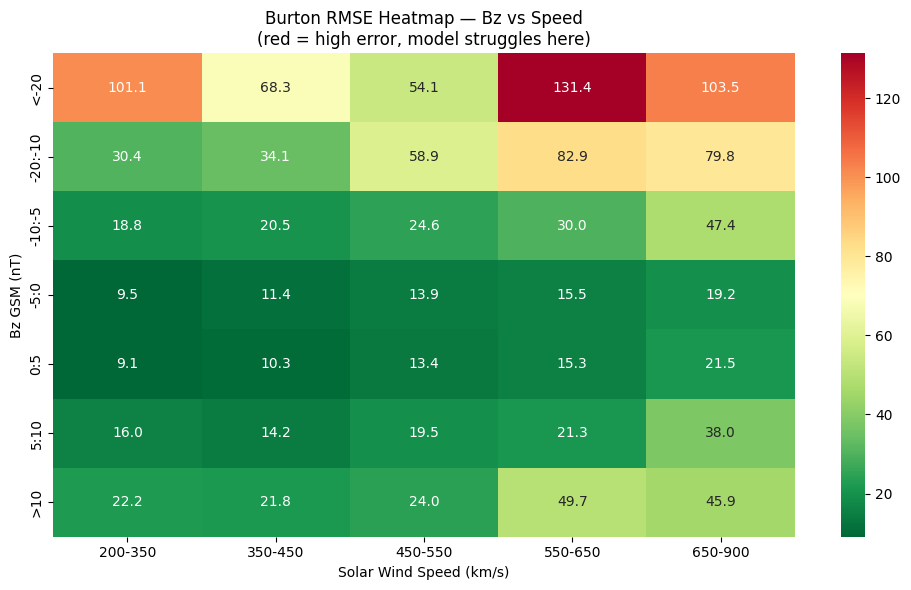

In [22]:
import seaborn as sns
df_reload = pd.read_parquet(DRIVE_PATH)
df_h = df_reload.dropna(subset=['residual']).reset_index(drop=True)

# Bin by Bz and Speed
df_h['bz_bin']    = pd.cut(df_h['bz_gsm'], bins=[-50,-20,-10,-5,0,5,10,50], labels=False)
df_h['speed_bin'] = pd.cut(df_h['speed'],  bins=[200,350,450,550,650,900],   labels=False)

pivot = df_h.groupby(['bz_bin','speed_bin'])['residual'].apply(
    lambda x: np.sqrt(np.mean(x**2))
).unstack()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.1f',
            xticklabels=['200-350','350-450','450-550','550-650','650-900'],
            yticklabels=['<-20','-20:-10','-10:-5','-5:0','0:5','5:10','>10'])
ax.set_xlabel('Solar Wind Speed (km/s)')
ax.set_ylabel('Bz GSM (nT)')
ax.set_title('Burton RMSE Heatmap — Bz vs Speed\n(red = high error, model struggles here)')
plt.tight_layout()
plt.savefig('error_heatmap_bz_speed.png', dpi=150)
plt.show()



  bz_gsm                   : 1.3024
  by_gsm                   : 0.7609
  bt                       : 1.0305
  density                  : 1.3978
  speed                    : 1.0672
  E_field                  : 0.7498
  Q                        : 1.1870
  dst_burton               : 2.2196
  dDst_dt                  : 1.1276
  rolling_error_3h         : 14.7577
  bz_gsm_mean_1h           : 1.2518
  bz_gsm_std_3h            : 0.9894
  speed_mean_3h            : 1.6997
  E_field_mean_6h          : 1.3721
  storm_phase              : 2.8471
  source_encoded           : 1.0859
  smoothed_ssn             : 0.9185


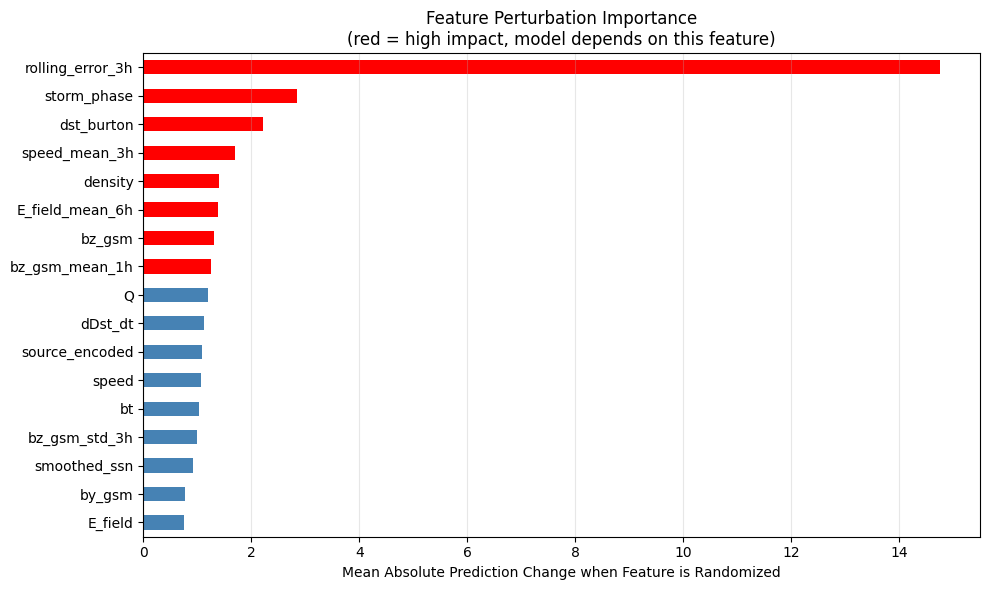

In [23]:
model.eval()
base_preds = []
with torch.no_grad():
    for x_batch, y_batch, w_batch in val_loader:
        base_preds.extend(model(x_batch.to(DEVICE)).cpu().numpy())
base_preds = np.array(base_preds)

importance = {}
for i, feat in enumerate(FEATURE_COLS):
    perturbed_preds = []
    with torch.no_grad():
        for x_batch, y_batch, w_batch in val_loader:
            x_perturbed = x_batch.clone()
            x_perturbed[:, :, i] = torch.randn_like(x_perturbed[:, :, i])  # replace with noise
            perturbed_preds.extend(model(x_perturbed.to(DEVICE)).cpu().numpy())
    perturbed_preds = np.array(perturbed_preds)
    importance[feat] = np.mean(np.abs(base_preds - perturbed_preds))
    print(f'  {feat:25s}: {importance[feat]:.4f}')

imp_df = pd.Series(importance).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if v > imp_df.median() else 'steelblue' for v in imp_df.values]
imp_df.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Mean Absolute Prediction Change when Feature is Randomized')
ax.set_title('Feature Perturbation Importance\n(red = high impact, model depends on this feature)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


Running Monte Carlo Dropout (30 forward passes)...


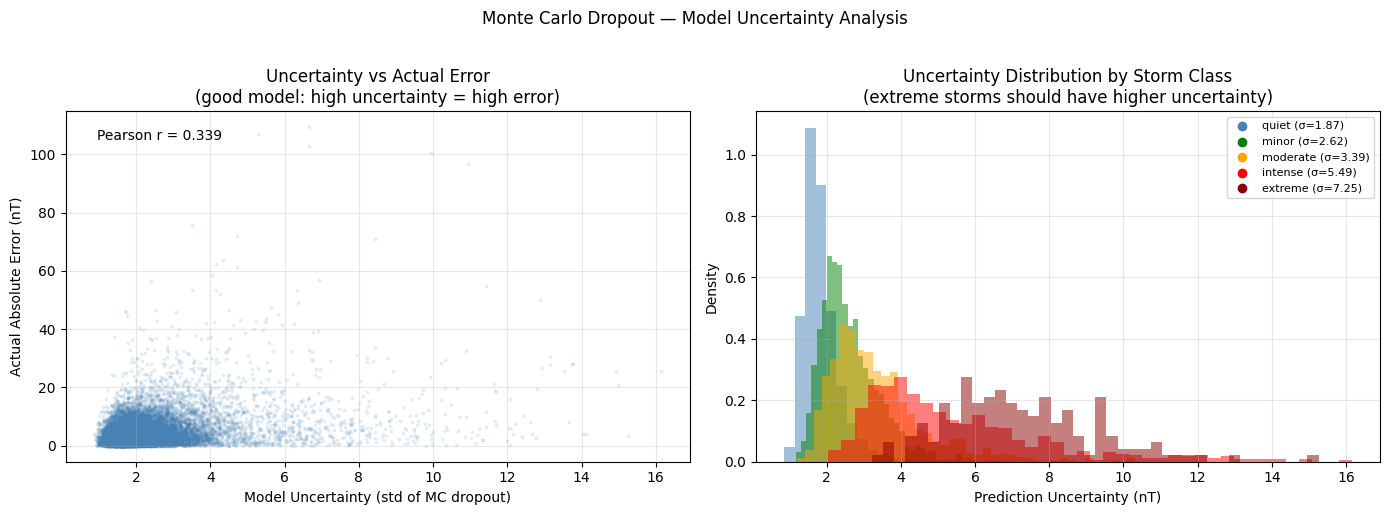


Correlation between uncertainty and error: 0.339
(closer to 1.0 = model knows when it is wrong)


In [24]:
def mc_predict(model, loader, n_samples=30):
    model.train()  # keep dropout active
    all_runs = []
    for _ in range(n_samples):
        run_preds = []
        with torch.no_grad():
            for x_batch, _, _ in loader:
                run_preds.extend(model(x_batch.to(DEVICE)).cpu().numpy())
        all_runs.append(run_preds)
    model.eval()
    all_runs = np.array(all_runs)  # (n_samples, n_val)
    mean_pred = all_runs.mean(axis=0)
    std_pred  = all_runs.std(axis=0)
    return mean_pred, std_pred

print('Running Monte Carlo Dropout (30 forward passes)...')
mc_mean, mc_std = mc_predict(model, val_loader, n_samples=30)

# Plot uncertainty vs actual error
actual_error = np.abs(mc_mean - all_targets)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uncertainty vs error scatter
axes[0].scatter(mc_std, actual_error, alpha=0.1, s=3, color='steelblue')
axes[0].set_xlabel('Model Uncertainty (std of MC dropout)')
axes[0].set_ylabel('Actual Absolute Error (nT)')
axes[0].set_title('Uncertainty vs Actual Error\n(good model: high uncertainty = high error)')
axes[0].grid(True, alpha=0.3)
corr = np.corrcoef(mc_std, actual_error)[0,1]
axes[0].text(0.05, 0.95, f'Pearson r = {corr:.3f}', transform=axes[0].transAxes,
             fontsize=10, va='top')

# Uncertainty by storm class
for label, w_val, color in [('quiet',1.0,'steelblue'),('minor',3.0,'green'),
                              ('moderate',10.0,'orange'),('intense',50.0,'red'),
                              ('extreme',200.0,'darkred')]:
    mask = all_weights == w_val
    if mask.sum() > 0:
        axes[1].scatter([], [], color=color, label=f'{label} (σ={mc_std[mask].mean():.2f})')

for label, w_val, color in [('quiet',1.0,'steelblue'),('minor',3.0,'green'),
                              ('moderate',10.0,'orange'),('intense',50.0,'red'),
                              ('extreme',200.0,'darkred')]:
    mask = all_weights == w_val
    if mask.sum() > 0:
        axes[1].hist(mc_std[mask], bins=40, alpha=0.5, color=color, density=True)

axes[1].set_xlabel('Prediction Uncertainty (nT)')
axes[1].set_ylabel('Density')
axes[1].set_title('Uncertainty Distribution by Storm Class\n(extreme storms should have higher uncertainty)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Monte Carlo Dropout — Model Uncertainty Analysis', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('mc_uncertainty.png', dpi=150)
plt.show()

print(f'\nCorrelation between uncertainty and error: {corr:.3f}')
print('(closer to 1.0 = model knows when it is wrong)')


Found 354 storms (Dst < -50 nT)
       actual_min  burton_min  residual_at_min  burton_error
count  354.000000  354.000000       354.000000    354.000000
mean   -82.457627  -75.592125       -14.503131      6.865502
std     45.327885   63.329193        34.007133     38.231644
min   -387.000000 -525.651367      -142.130493   -255.057861
25%    -87.000000  -85.788273       -30.950259     -5.077467
50%    -68.000000  -56.346130       -13.869625      9.491684
75%    -56.000000  -41.981026        -0.902473     24.434748
max    -51.000000   -4.343194       246.680664    142.130493


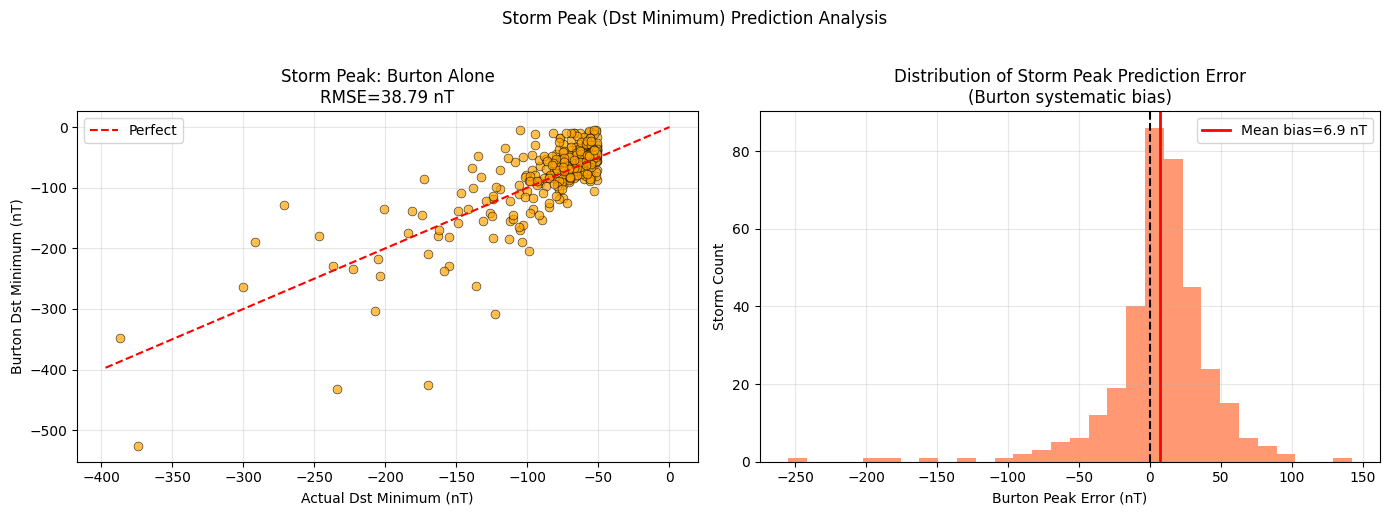

In [25]:
df_reload = pd.read_parquet(DRIVE_PATH)
df_h = df_reload.dropna(subset=['residual']).reset_index(drop=True)

storm_records = []
for period in df_h['period'].unique():
    sub = df_h[df_h['period'] == period].reset_index(drop=True)
    # Find storms: Dst drops below -50
    in_storm = False
    storm_start = 0
    for i in range(len(sub)):
        if sub.loc[i,'dst'] < -50 and not in_storm:
            in_storm = True
            storm_start = i
        elif sub.loc[i,'dst'] >= -30 and in_storm:
            storm_end = i
            storm = sub.iloc[storm_start:storm_end]
            actual_min  = storm['dst'].min()
            burton_min  = storm['dst_burton'].min()
            residual_at_min = storm.loc[storm['dst'].idxmin(), 'residual']
            storm_records.append({
                'period':       period,
                'actual_min':   actual_min,
                'burton_min':   burton_min,
                'residual_at_min': residual_at_min,
                'burton_error': burton_min - actual_min,
            })
            in_storm = False

df_storms = pd.DataFrame(storm_records)
print(f'Found {len(df_storms)} storms (Dst < -50 nT)')
print(df_storms.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_storms['actual_min'], df_storms['burton_min'],
                alpha=0.7, s=40, color='orange', edgecolors='black', lw=0.5)
lim = df_storms['actual_min'].min() - 10
axes[0].plot([lim, 0], [lim, 0], 'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('Actual Dst Minimum (nT)')
axes[0].set_ylabel('Burton Dst Minimum (nT)')
axes[0].set_title(f'Storm Peak: Burton Alone\nRMSE={np.sqrt((df_storms["burton_error"]**2).mean()):.2f} nT')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(df_storms['burton_error'], bins=30, color='coral', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].axvline(df_storms['burton_error'].mean(), color='red', lw=2,
                label=f'Mean bias={df_storms["burton_error"].mean():.1f} nT')
axes[1].set_xlabel('Burton Peak Error (nT)')
axes[1].set_ylabel('Storm Count')
axes[1].set_title('Distribution of Storm Peak Prediction Error\n(Burton systematic bias)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Storm Peak (Dst Minimum) Prediction Analysis', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('storm_peak_analysis.png', dpi=150)
plt.show()


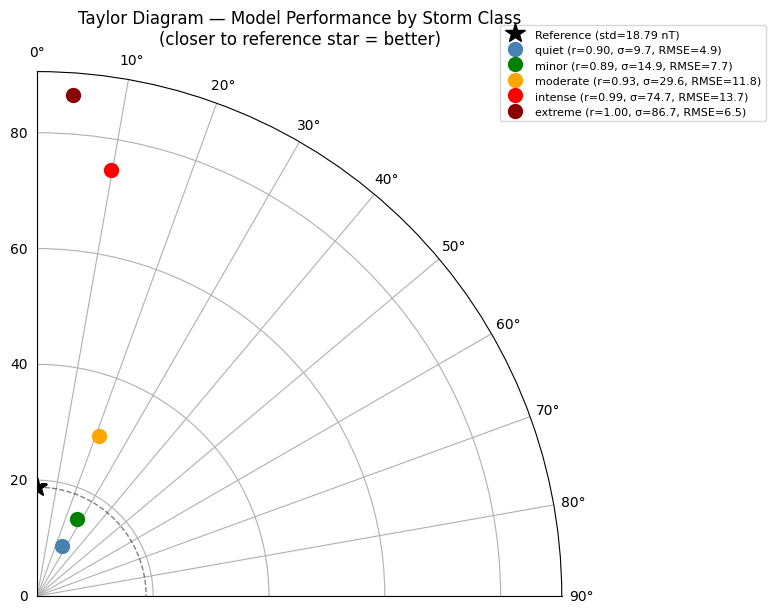

In [26]:
def taylor_diagram(ax, std_ref, std_pred, corr, label, color, marker='o'):
    theta = np.arccos(corr)
    r     = std_pred
    x     = r * np.cos(theta)
    y     = r * np.sin(theta)
    ax.plot(x, y, marker=marker, ms=10, color=color, label=label)
    return x, y

std_ref = np.std(all_targets)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetamin(0)
ax.set_thetamax(90)

# Reference point (perfect model)
ax.plot(0, std_ref, 'k*', ms=15, label=f'Reference (std={std_ref:.2f} nT)')

colors = ['steelblue','green','orange','red','darkred']
for (label, w_val, color) in zip(
    ['quiet','minor','moderate','intense','extreme'],
    [1.0, 3.0, 10.0, 50.0, 200.0],
    colors
):
    mask = all_weights == w_val
    if mask.sum() < 5: continue
    t = all_targets[mask]
    p = all_preds[mask]
    std_p = np.std(p)
    corr  = np.corrcoef(t, p)[0,1]
    rmse  = np.sqrt(np.mean((p-t)**2))
    theta = np.arccos(np.clip(corr, -1, 1))
    ax.plot(theta, std_p, 'o', ms=10, color=color,
            label=f'{label} (r={corr:.2f}, σ={std_p:.1f}, RMSE={rmse:.1f})')

# Reference std arc
theta_arc = np.linspace(0, np.pi/2, 100)
ax.plot(theta_arc, [std_ref]*100, 'k--', lw=1, alpha=0.5)

ax.set_title('Taylor Diagram — Model Performance by Storm Class\n'
             '(closer to reference star = better)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig('taylor_diagram.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 15 — Save scaler and model config

In [27]:
# Save scaler (needed for inference)
with open('corrector_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save config (needed to rebuild model at inference time)
config = {
    'input_size':    len(FEATURE_COLS),
    'hidden_size':   HIDDEN_SIZE,
    'num_layers':    NUM_LAYERS,
    'dropout':       DROPOUT,
    'seq_len':       SEQ_LEN,
    'feature_cols':  FEATURE_COLS,
    'target_col':    TARGET_COL,
    'best_val_loss': float(best_val),
    'val_rmse_nT':   float(rmse),
    'val_rmse_by_class': {
        'quiet':    float(np.sqrt(np.mean((all_preds[all_weights==1.0]   - all_targets[all_weights==1.0])**2))),
        'minor':    float(np.sqrt(np.mean((all_preds[all_weights==3.0]   - all_targets[all_weights==3.0])**2))),
        'moderate': float(np.sqrt(np.mean((all_preds[all_weights==10.0]  - all_targets[all_weights==10.0])**2))),
        'intense':  float(np.sqrt(np.mean((all_preds[all_weights==50.0]  - all_targets[all_weights==50.0])**2))),
        'extreme':  float(np.sqrt(np.mean((all_preds[all_weights==200.0] - all_targets[all_weights==200.0])**2))),
    }
}
with open('corrector_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved:')
print('  corrector_model.pt      — model weights')
print('  corrector_scaler.pkl    — StandardScaler')
print('  corrector_config.json   — hyperparameters + feature list')
print()
print('Val RMSE by storm class:')
for cls, r in config['val_rmse_by_class'].items():
    print(f'  {cls:10s}: {r:.2f} nT')


Saved:
  corrector_model.pt      — model weights
  corrector_scaler.pkl    — StandardScaler
  corrector_config.json   — hyperparameters + feature list

Val RMSE by storm class:
  quiet     : 4.91 nT
  minor     : 7.74 nT
  moderate  : 11.84 nT
  intense   : 13.71 nT
  extreme   : 6.50 nT


## Cell 16 — Download all artifacts from Colab

In [28]:
from google.colab import files
import os

artifacts = [
    'corrector_model.pt',
    'corrector_scaler.pkl',
    'corrector_config.json',
    'corrector_training_curve.png',
    'corrector_scatter.png',
    'dst_per_category.png',
    'error_heatmap_bz_speed.png',
    'feature_importance.png',
    'mc_uncertainty.png',
    'storm_peak_analysis.png',
    'taylor_diagram.png',
    'skill_score.png',
    'cumulative_error.png',
    'dst_reconstruction.png',
    'error_vs_dst.png',
    'final_dst_comparison.png',
    'storm_case_study.png',
]

for f in artifacts:
    if os.path.exists(f):
        files.download(f)
        print(f'Downloaded: {f}')
    else:
        print(f'Skipped (not found): {f}')

print('\nDownload complete!')
print('Place model files in models/ folder:')
print('  models/corrector_model.pt')
print('  models/corrector_scaler.pkl')
print('  models/corrector_config.json')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: corrector_model.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: final_dst_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: storm_case_study.png

Download complete!
Place model files in models/ folder:
  models/corrector_model.pt
  models/corrector_scaler.pkl
  models/corrector_config.json
